In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import os

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project5-optimization_charts", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL", "KO", "^GSPC", "NVDA", "GC=F", "MSFT"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-07-02,136.426270,1782.599976,46.730694,266.459778,20.416374,4352.339844
2021-07-06,138.434265,1793.500000,46.471939,266.469391,20.627153,4343.540039
2021-07-07,140.919861,1801.500000,46.851448,268.647919,20.301529,4358.129883
2021-07-08,139.623459,1799.599976,46.687569,266.239044,19.834145,4320.819824
2021-07-09,141.446243,1810.000000,46.972195,266.738068,19.981136,4369.549805
...,...,...,...,...,...,...
2026-06-24,293.079987,3990.300049,80.599998,365.459991,199.000000,7358.220215
2026-06-25,275.149994,4030.500000,80.419998,352.829987,195.740005,7357.490234
2026-06-26,283.779999,4078.699951,82.629997,372.970001,192.529999,7354.020020


In [23]:
returns = df.pct_change().dropna()
returns

C:\Users\yashr\AppData\Local\Temp\ipykernel_28524\119691768.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-07-06,0.014719,0.006115,-0.005537,0.000036,0.010324,-0.002022
2021-07-07,0.017955,0.004461,0.008166,0.008176,-0.015786,0.003359
2021-07-08,-0.009200,-0.001055,-0.003498,-0.008967,-0.023022,-0.008561
2021-07-09,0.013055,0.005779,0.006096,0.001874,0.007411,0.011278
2021-07-12,-0.004204,-0.002486,0.000367,-0.002231,0.023055,0.003451
...,...,...,...,...,...,...
2026-06-24,-0.004145,-0.033802,0.003611,-0.022677,-0.005199,-0.000983
2026-06-25,-0.061178,0.010074,-0.002233,-0.034559,-0.016382,-0.000099
2026-06-26,0.031365,0.011959,0.027481,0.057081,-0.016399,-0.000472


In [24]:
covariance = returns.cov()*252
covariance

Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Ticker,,,,,,
AAPL,0.076744,0.001061,0.011379,0.042799,0.070426,0.034955
GC=F,0.001061,0.034255,0.000980,0.001712,0.003903,0.002952
KO,0.011379,0.000980,0.026314,0.006176,-0.001347,0.007859
MSFT,0.042799,0.001712,0.006176,0.072666,0.082613,0.032733
NVDA,0.070426,0.003903,-0.001347,0.082613,0.268462,0.062513
^GSPC,0.034955,0.002952,0.007859,0.032733,0.062513,0.028923


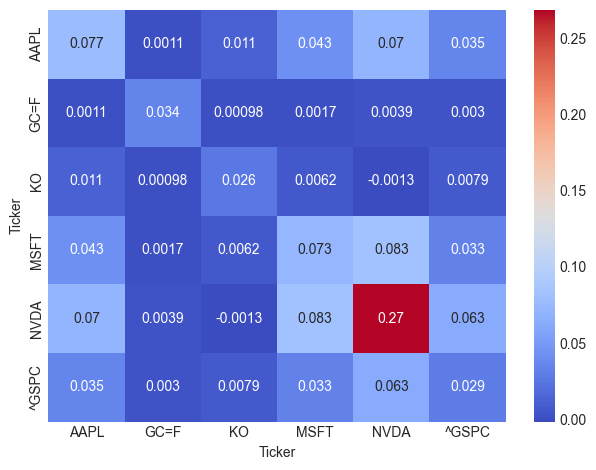

In [25]:
sns.heatmap(covariance, cmap = 'coolwarm', annot = True)

plt.tight_layout()
plt.savefig("project5-optimization_charts/covariance_heatmap.png", dpi=300, bbox_inches="tight")

In [26]:
annualreturns = returns.mean()*252

In [27]:
def simulate(maxweight, num_simulations = 10000):
    num_assets = len(stocks)
    allweights = np.random.default_rng().dirichlet(np.ones(num_assets), size=num_simulations)

    returns_list = []
    volatility_list = []
    sharpe_list = []

    accepted_weights = []

    for weight in allweights:
        if np.any(weight > maxweight):
            continue
        portfolioreturn = (annualreturns*weight).sum()
        returns_list.append(portfolioreturn)

        portfoliovariance = weight.T @ covariance @ weight

        portfoliovolatility = np.sqrt(portfoliovariance)
        volatility_list.append(portfoliovolatility)
        
        sharpe = portfolioreturn/portfoliovolatility
        sharpe_list.append(sharpe)

        accepted_weights.append(weight)
    
    data = {
    'Returns': returns_list,
    'Volatility': volatility_list,
    'Sharpe': sharpe_list
}

    frontier = pd.DataFrame(data)
    return frontier, accepted_weights
    

In [28]:
frontier, accepted_weights = simulate(1.0)
frontier.shape

(10000, 3)

In [29]:
max_sharpe_idx = frontier['Sharpe'].idxmax()
min_vol_idx = frontier['Volatility'].idxmin()

In [30]:
msr_portfolio = frontier.loc[max_sharpe_idx]
mvp_portfolio = frontier.loc[min_vol_idx]

In [31]:
best_weights = accepted_weights[max_sharpe_idx]

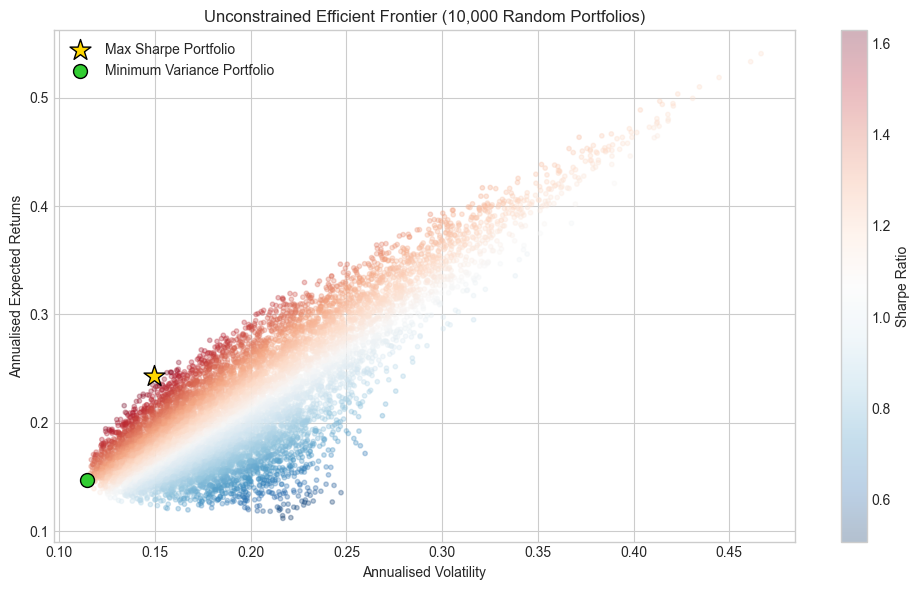

In [32]:
plt.figure(figsize=(10, 6))

# Plot all 10,000 random portfolios
scatter = plt.scatter(
    frontier['Volatility'], 
    frontier['Returns'], 
    c=frontier['Sharpe'], 
    #cmap='RdYlBu_r', 
    cmap = 'RdBu_r',
    s=10, 
    alpha=0.3
)

plt.scatter(
    msr_portfolio['Volatility'],
    msr_portfolio['Returns'],
    color='gold',
    marker='*',
    s=250,
    edgecolor='black',
    label='Max Sharpe Portfolio'
)

# Minimum Variance Portfolio
plt.scatter(
    mvp_portfolio['Volatility'],
    mvp_portfolio['Returns'],
    color='limegreen',
    marker='o',
    s=100,
    edgecolor='black',
    label='Minimum Variance Portfolio'
)

plt.legend()

# Add a color bar on the side to show what the colors mean
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Expected Returns')
plt.title("Unconstrained Efficient Frontier (10,000 Random Portfolios)")

plt.tight_layout()
plt.savefig("project5-optimization_charts/efficient_frontier.png", dpi=300, bbox_inches="tight")


In [33]:
frontier.loc[frontier['Sharpe'].idxmax()]

Returns       0.243450
Volatility    0.149547
Sharpe        1.627915
Name: 2749, dtype: float64

In [34]:
frontier.loc[frontier['Volatility'].idxmin()]

Returns       0.146806
Volatility    0.114679
Sharpe        1.280151
Name: 7620, dtype: float64

In [35]:
newfrontier, newaccepted_weights = simulate(0.3)
newfrontier.shape

(1456, 3)

In [36]:
newmax_sharpe_idx = newfrontier['Sharpe'].idxmax()
newmin_vol_idx = newfrontier['Volatility'].idxmin()

newmsr_portfolio = newfrontier.loc[newmax_sharpe_idx]
newmvp_portfolio = newfrontier.loc[newmin_vol_idx]

newbest_weights = newaccepted_weights[newmax_sharpe_idx]

Accepted Portfolios: 1,456
Acceptance Rate: 14.6%


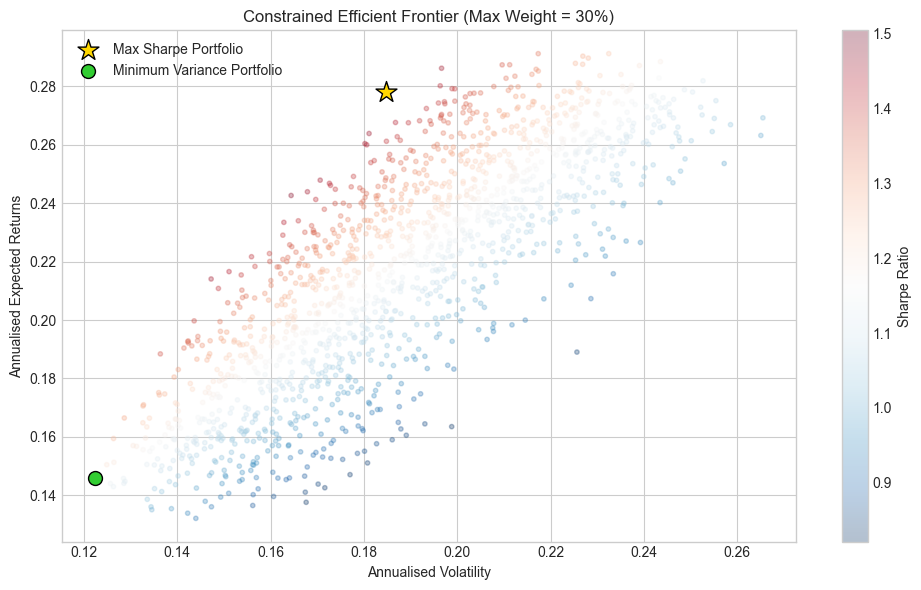

In [37]:
plt.figure(figsize=(10, 6))

# Plot all 10,000 random portfolios
scatter = plt.scatter(
    newfrontier['Volatility'], 
    newfrontier['Returns'], 
    c=newfrontier['Sharpe'], 
    #cmap='RdYlBu_r', 
    cmap = 'RdBu_r',
    s=10, 
    alpha=0.3
)

plt.scatter(
    newmsr_portfolio['Volatility'],
    newmsr_portfolio['Returns'],
    color='gold',
    marker='*',
    s=250,
    edgecolor='black',
    label='Max Sharpe Portfolio'
)

# Minimum Variance Portfolio
plt.scatter(
    newmvp_portfolio['Volatility'],
    newmvp_portfolio['Returns'],
    color='limegreen',
    marker='o',
    s=100,
    edgecolor='black',
    label='Minimum Variance Portfolio'
)

plt.legend()


# Add a color bar on the side to show what the colors mean
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Expected Returns')

plt.title("Constrained Efficient Frontier (Max Weight = 30%)")

print(f"Accepted Portfolios: {len(newaccepted_weights):,}")
print(f"Acceptance Rate: {len(newaccepted_weights)/10000:.1%}")

plt.tight_layout()
plt.savefig("project5-optimization_charts/constrained_frontier.png", dpi=300, bbox_inches="tight")

In [38]:
newfrontier.loc[newfrontier['Sharpe'].idxmax()]
newfrontier.loc[newfrontier['Volatility'].idxmin()]

Returns       0.145925
Volatility    0.122389
Sharpe        1.192307
Name: 783, dtype: float64

In [39]:
comparison_summary = pd.DataFrame({
    "Unconstrained": msr_portfolio,
    "Constrained": newmsr_portfolio
}).round(3)

comparison_summary

,Unconstrained,Constrained
Returns,0.243,0.278
Volatility,0.150,0.185
Sharpe,1.628,1.505


In [40]:
optimal_weights = pd.DataFrame({
    "Asset": stocks,
    "Unconstrained": best_weights,
    "Constrained": newbest_weights
})

optimal_weights

,Asset,Unconstrained,Constrained
0,AAPL,0.008427,0.113452
1,KO,0.464190,0.291627
2,^GSPC,0.309268,0.286563
3,NVDA,0.016438,0.000779
4,GC=F,0.198204,0.277585
5,MSFT,0.003473,0.029994


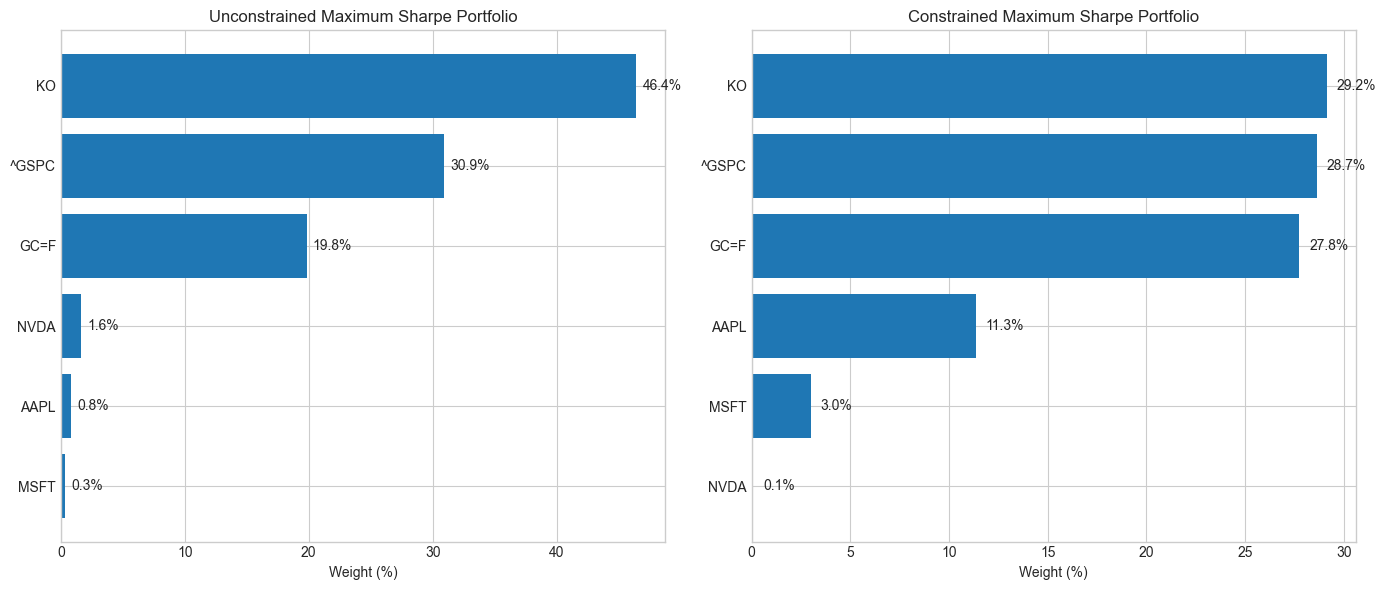

In [41]:
weights_df = pd.DataFrame({
    "Asset": stocks,
    "Weight": best_weights * 100
})

weights_df = weights_df.sort_values("Weight", ascending=True)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.barh(weights_df["Asset"], weights_df["Weight"])
ax1.set_xlabel("Weight (%)")
ax1.set_title("Unconstrained Maximum Sharpe Portfolio")

for i, value in enumerate(weights_df["Weight"]):
    ax1.text(value + 0.5, i, f"{value:.1f}%", va="center")

constrainedweights_df = pd.DataFrame({
    "Asset": stocks,
    "Weight": newbest_weights * 100
})

constrainedweights_df = constrainedweights_df.sort_values("Weight", ascending=True)

ax2.barh(constrainedweights_df["Asset"], constrainedweights_df["Weight"])
ax2.set_xlabel("Weight (%)")
ax2.set_title("Constrained Maximum Sharpe Portfolio")

for i, value in enumerate(constrainedweights_df["Weight"]):
    ax2.text(value + 0.5, i, f"{value:.1f}%", va="center")


plt.tight_layout()
plt.savefig("project5-optimization_charts/max_sharpe_weights.png", dpi=300, bbox_inches="tight")

In [42]:
comparison = pd.DataFrame({
    "Metric": ["Return", "Volatility", "Sharpe"],
    "Unconstrained": [
        msr_portfolio["Returns"],
        msr_portfolio["Volatility"],
        msr_portfolio["Sharpe"]
    ],
    "Constrained": [
        newmsr_portfolio["Returns"],
        newmsr_portfolio["Volatility"],
        newmsr_portfolio["Sharpe"]
    ]
})

comparison = comparison.round(3)

comparison

,Metric,Unconstrained,Constrained
0,Return,0.243,0.278
1,Volatility,0.150,0.185
2,Sharpe,1.628,1.505
